In [28]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from scipy.stats import kruskal, shapiro, f_oneway
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Preprocessing

In [29]:
df_base = pd.read_csv('./data/Attack-B-Results.csv')
df_base.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,BIM_LA_Loss
0,1V,True,True,0.012069,0.105367,NaN,NaN,NaN,NaN
1,1V,True,True,0.011992,0.054891,NaN,NaN,NaN,NaN
2,1V,True,True,0.011487,0.106672,NaN,NaN,NaN,NaN
3,1V,True,True,0.012184,0.065032,NaN,NaN,NaN,NaN
4,1V,True,True,0.011993,0.057964,NaN,NaN,NaN,NaN


In [30]:
df_test = df_base.loc[
    (df_base['image_attack'] == True) &
    (df_base['sketch_attack'] == False)
].copy().reset_index(drop=True)

df_test['BIM_IM_Abs_Increase'] = (
    df_test['BIM_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['BIM_IM_Rel_Increase'] = (
    df_test['BIM_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test

,model,image_attack,sketch_attack,Clean_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,BIM_LA_Loss,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,1V,True,False,0.012069,0.105367,NaN,NaN,NaN,NaN,0.093298,773.061380
1,1V,True,False,0.011992,0.054891,NaN,NaN,NaN,NaN,0.042899,357.722888
2,1V,True,False,0.011487,0.106672,NaN,NaN,NaN,NaN,0.095186,828.668379
3,1V,True,False,0.012184,0.065032,NaN,NaN,NaN,NaN,0.052848,433.729969
4,1V,True,False,0.011993,0.057964,NaN,NaN,NaN,NaN,0.045970,383.300156
5,1V,True,False,0.011453,0.122069,NaN,NaN,NaN,NaN,0.110616,965.863262
6,1V,True,False,0.011325,0.173747,NaN,NaN,NaN,NaN,0.162422,1434.187672
7,1V,True,False,0.011503,0.117177,NaN,NaN,NaN,NaN,0.105674,918.653177
8,1V,True,False,0.012171,0.042700,NaN,NaN,NaN,NaN,0.030529,250.841596
9,1V,True,False,0.012688,0.049429,NaN,NaN,NaN,NaN,0.036741,289.572643


In [31]:
df_mean = (
    df_test
        .groupby(['model', 'image_attack', 'sketch_attack'], as_index=False)[['Clean_IM_Loss', 'BIM_IM_Loss', 'BIM_IM_Abs_Increase', 'BIM_IM_Rel_Increase']]
        .mean()
        .round(3)
        .reset_index()
)

df_mean

,index,model,image_attack,sketch_attack,Clean_IM_Loss,BIM_IM_Loss,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,0,1V,True,False,0.012,0.090,0.078,663.560
1,1,2V-IL,True,False,0.014,0.104,0.089,619.212
2,2,2V-IS,True,False,0.015,0.106,0.090,588.995
3,3,3V,True,False,0.015,0.192,0.177,1167.042


## Plots

In [32]:
model_order = ['1V', '2V-IS', '2V-IL', '3V']

model_color_map = {
    '1V': 'tab:blue',
    '2V-IS': 'tab:orange',
    '2V-IL': '#ffb066',
    '3V': 'tab:red',
}

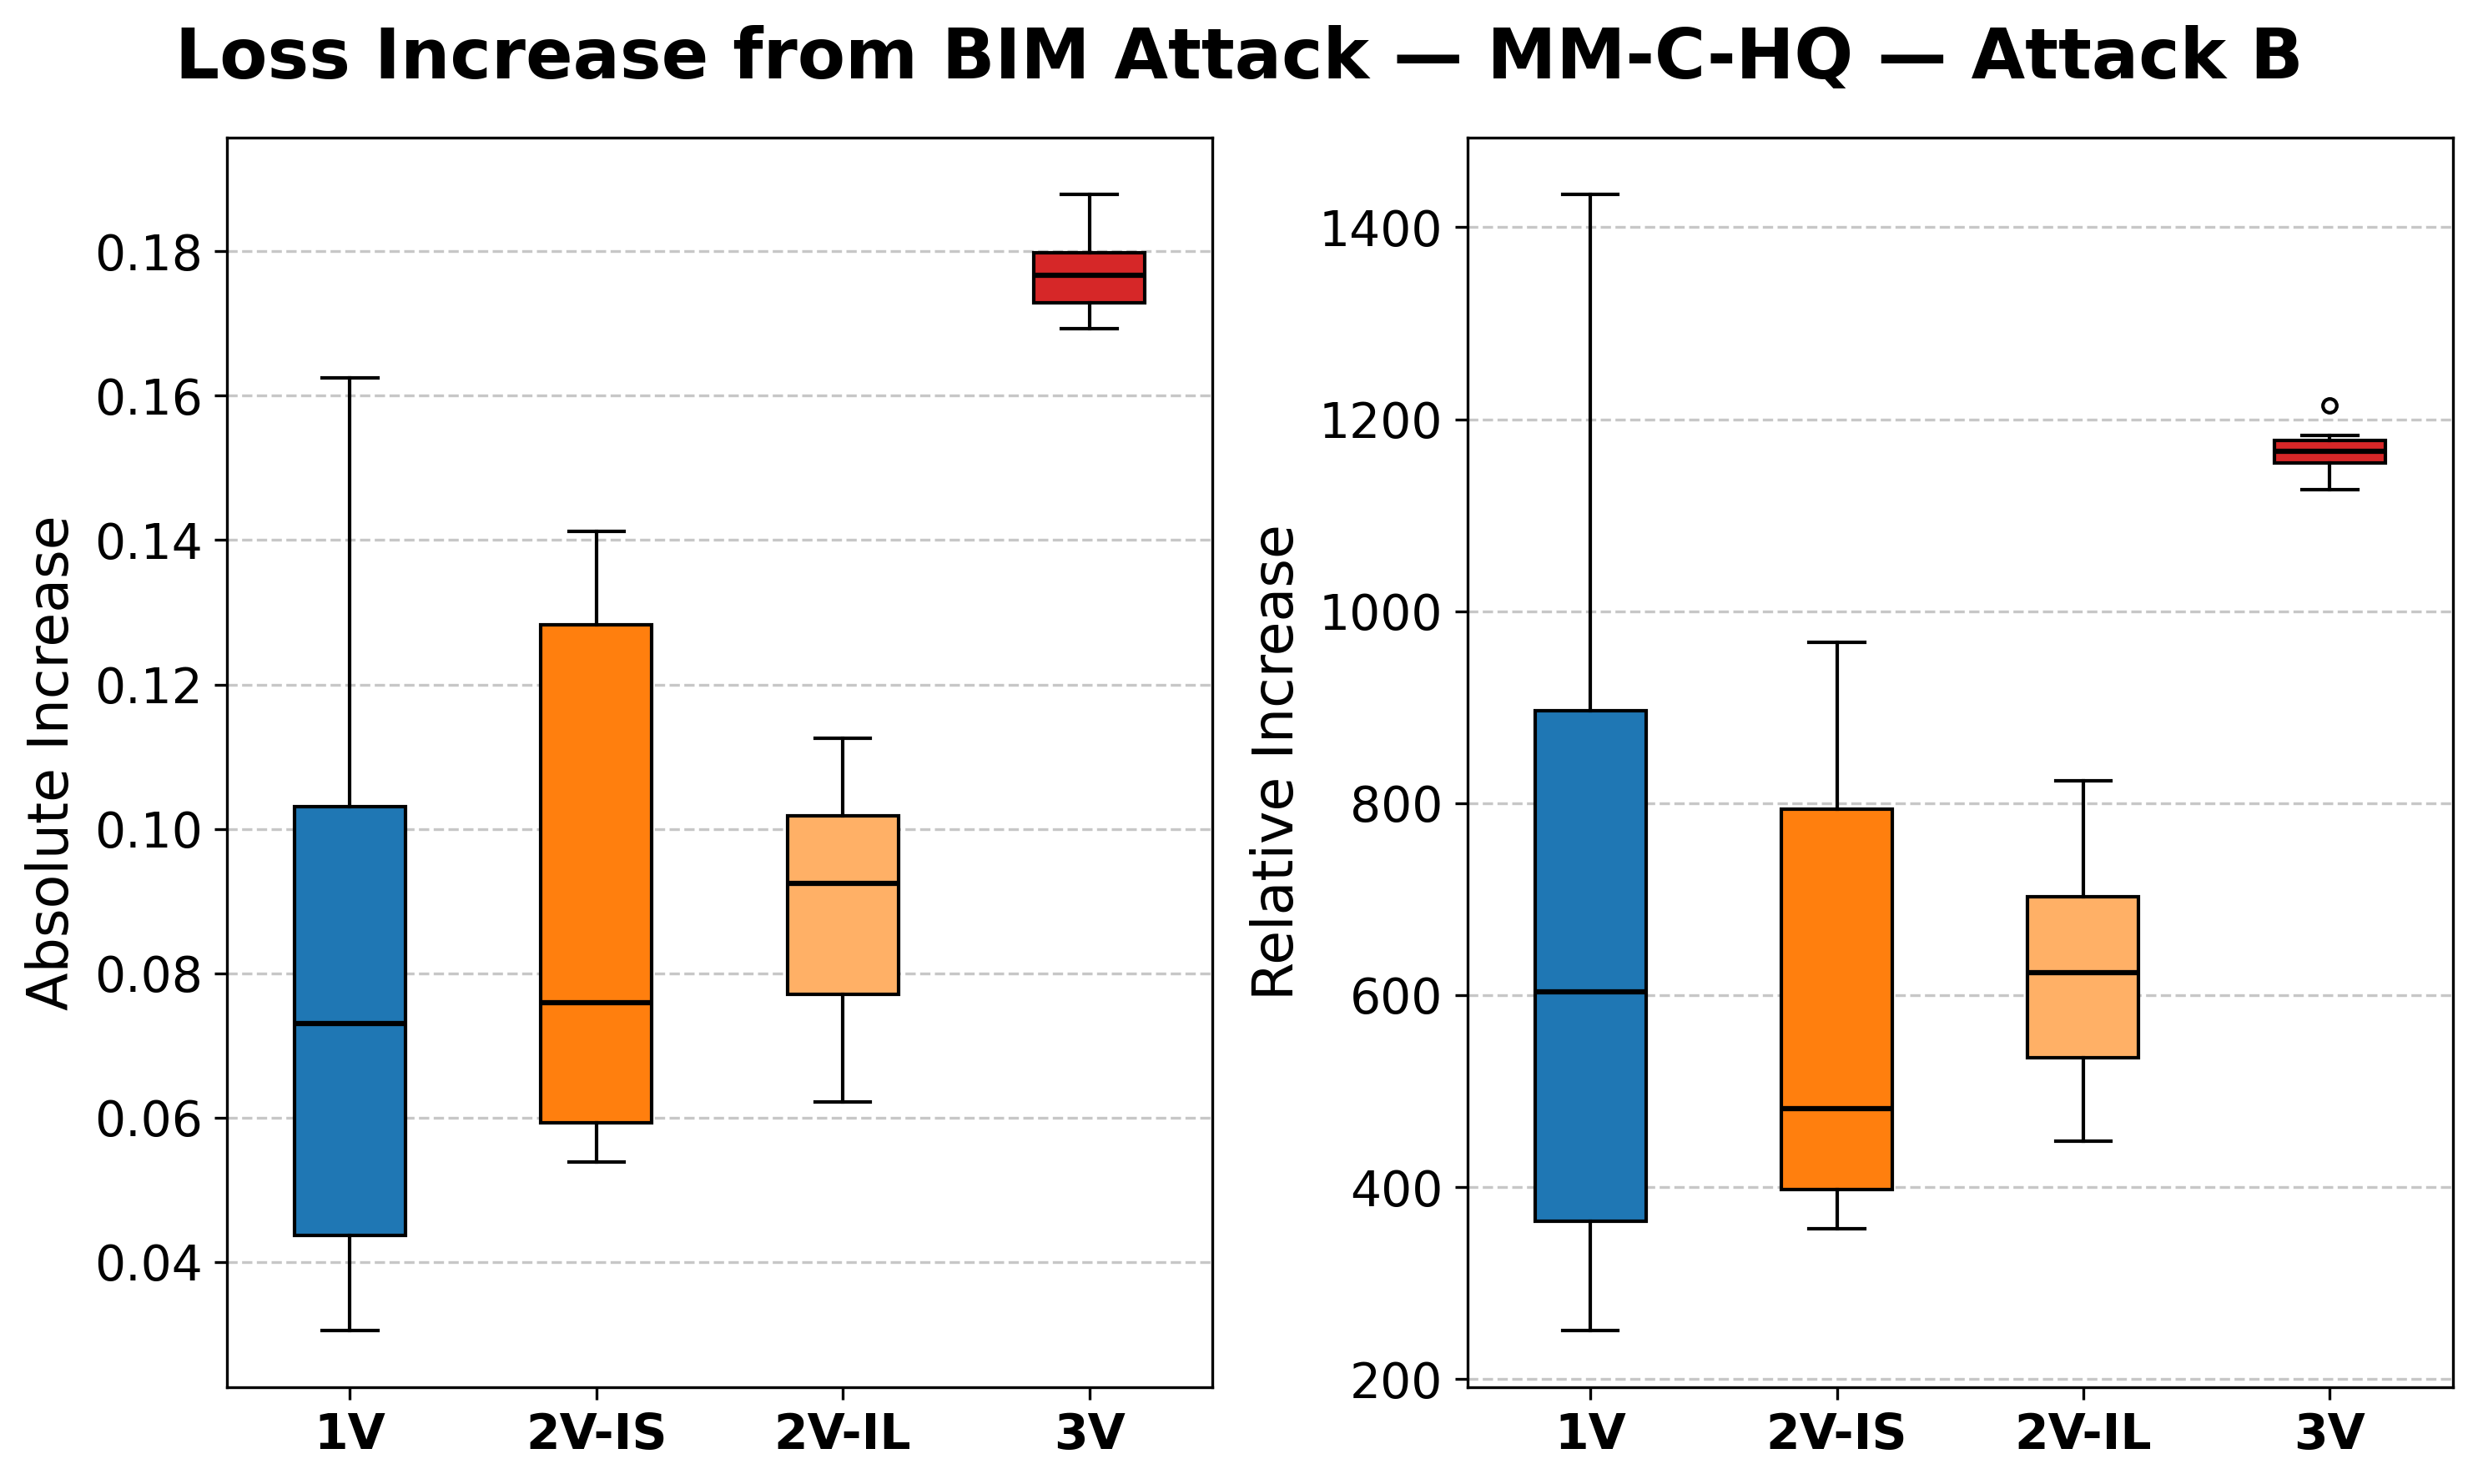

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=300)

plot_specs = [
    (
        'BIM_IM_Abs_Increase',
        'Absolute Increase',
        'Absolute Image Loss Increase',
    ),
    (
        'BIM_IM_Rel_Increase',
        'Relative Increase',
        'Relative Image Loss Increase',
    ),
]

model_positions = np.arange(len(model_order))

for ax, (col, ylabel, title) in zip(axes, plot_specs):
    values = [
        df_test.loc[df_test['model'].eq(model), col].dropna().to_numpy()
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        positions=model_positions,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
    )

    for patch, model in zip(box['boxes'], model_order):
        patch.set_facecolor(model_color_map[model])
        patch.set_edgecolor('black')

    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in box['whiskers']:
        whisker.set_color('black')

    for cap in box['caps']:
        cap.set_color('black')

    for flier in box['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor('white')
        flier.set_markeredgecolor('black')
        flier.set_markersize(4)

    ax.set_ylabel(ylabel, fontsize=16)

    ax.set_xticks(model_positions)
    ax.set_xticklabels(model_order, fontsize=14, fontweight='bold')

    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Loss Increase from BIM Attack — MM-C-HQ — Attack B', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/attack-B-image-loss-increases-boxplots.png', bbox_inches='tight')
plt.show()

## Statistical Tests
### Normality

In [34]:
test_cols = [
    'BIM_IM_Loss',
    'BIM_IM_Abs_Increase',
    'BIM_IM_Rel_Increase',
]

In [35]:
normality_results = []

for col in test_cols:
    print(f'\n===== {col} =====')

    for model in model_order:
        values = (
            df_test
            .loc[df_test['model'].eq(model), col]
            .dropna()
            .to_numpy()
        )

        w_stat, p_value = shapiro(values)

        normality_results.append({
            'metric': col,
            'model': model,
            'W': w_stat,
            'p': p_value,
            'normal': p_value > 0.05,
        })

        print(f'{model}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)
normality_df


===== BIM_IM_Loss =====
1V: W = 0.8972, p = 0.2040
2V-IS: W = 0.8236, p = 0.0280
2V-IL: W = 0.9100, p = 0.2810
3V: W = 0.9453, p = 0.6135

===== BIM_IM_Abs_Increase =====
1V: W = 0.8979, p = 0.2076
2V-IS: W = 0.8238, p = 0.0282
2V-IL: W = 0.9208, p = 0.3638
3V: W = 0.9484, p = 0.6499

===== BIM_IM_Rel_Increase =====
1V: W = 0.8967, p = 0.2017
2V-IS: W = 0.8429, p = 0.0478
2V-IL: W = 0.9533, p = 0.7071
3V: W = 0.9723, p = 0.9112


,metric,model,W,p,normal
0,BIM_IM_Loss,1V,0.897187,0.203999,True
1,BIM_IM_Loss,2V-IS,0.823612,0.028021,False
2,BIM_IM_Loss,2V-IL,0.910004,0.281018,True
3,BIM_IM_Loss,3V,0.945311,0.613465,True
4,BIM_IM_Abs_Increase,1V,0.897878,0.207617,True
5,BIM_IM_Abs_Increase,2V-IS,0.823777,0.028151,False
6,BIM_IM_Abs_Increase,2V-IL,0.920815,0.363801,True
7,BIM_IM_Abs_Increase,3V,0.948421,0.649857,True
8,BIM_IM_Rel_Increase,1V,0.896741,0.201689,True
9,BIM_IM_Rel_Increase,2V-IS,0.842938,0.047846,False


## Significance

In [36]:
kruskal_results = []

for col in test_cols:
    groups = [
        df_test
        .loc[df_test['model'].eq(model), col]
        .dropna()
        .to_numpy()
        for model in model_order
    ]

    h_stat, p_value = kruskal(*groups)

    kruskal_results.append({
        'metric': col,
        'H': h_stat,
        'p': p_value,
        'significant': p_value < 0.05,
    })

    print(f'\n===== {col} =====')
    print(f'H-statistic: {h_stat:.6f}')
    print(f'p-value: {p_value:.6e}')

kruskal_df = pd.DataFrame(kruskal_results)
kruskal_df


===== BIM_IM_Loss =====
H-statistic: 22.892195
p-value: 4.252724e-05

===== BIM_IM_Abs_Increase =====
H-statistic: 22.835122
p-value: 4.370796e-05

===== BIM_IM_Rel_Increase =====
H-statistic: 19.289268
p-value: 2.382131e-04


,metric,H,p,significant
0,BIM_IM_Loss,22.892195,0.000043,True
1,BIM_IM_Abs_Increase,22.835122,0.000044,True
2,BIM_IM_Rel_Increase,19.289268,0.000238,True


## Post-Hoc

In [37]:
def dunn_letter_display(
    data,
    value_col,
    group_col='model',
    group_order=None,
    alpha=0.05,
    p_adjust='holm',
):
    if group_order is None:
        group_order = sorted(data[group_col].dropna().unique())

    dunn_df = sp.posthoc_dunn(
        data,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust,
    )

    dunn_df = dunn_df.loc[group_order, group_order]

    reject_df = dunn_df < alpha

    means = (
        data
        .groupby(group_col)[value_col]
        .mean()
        .loc[group_order]
        .sort_values()
    )

    letters = {group: '' for group in means.index}
    available_letters = list(string.ascii_lowercase)

    for group in means.index:
        for letter in available_letters:
            groups_with_letter = [
                other_group
                for other_group, assigned_letters in letters.items()
                if letter in assigned_letters
            ]

            can_share_letter = all(
                not reject_df.loc[group, other_group]
                for other_group in groups_with_letter
            )

            if can_share_letter:
                letters[group] += letter
                break

        if letters[group] == '':
            new_letter = available_letters[
                max(
                    [available_letters.index(l) for ls in letters.values() for l in ls],
                    default=-1,
                ) + 1
            ]
            letters[group] += new_letter

    letter_df = pd.DataFrame({
        group_col: group_order,
        'mean': data.groupby(group_col)[value_col].mean().loc[group_order].values,
        'letters': [letters[group] for group in group_order],
    })

    return dunn_df, letter_df

In [38]:
for col in test_cols:
    print(f'\n===== {col} =====')

    dunn_df, letter_df = dunn_letter_display(
        df_test,
        value_col=col,
        group_col='model',
        group_order=model_order,
        alpha=0.05,
        p_adjust='holm',
    )

    display(letter_df)


===== BIM_IM_Loss =====


,model,mean,letters
0,1V,0.089505,a
1,2V-IS,0.105563,a
2,2V-IL,0.103568,a
3,3V,0.192091,b



===== BIM_IM_Abs_Increase =====


,model,mean,letters
0,1V,0.077618,a
1,2V-IS,0.090220,a
2,2V-IL,0.089169,a
3,3V,0.176923,b



===== BIM_IM_Rel_Increase =====


,model,mean,letters
0,1V,663.560112,a
1,2V-IS,588.995084,a
2,2V-IL,619.211658,a
3,3V,1167.042170,b
